
# Model comparison: Model 1 vs Model 2

This notebook compares two fitted Bayesian models:

- **Model 1**: robust Student-t temperature-only model from `model_1_temperature_studentt.ipynb`,
- **Model 2**: robust temperature model with daily offsets from `model_2_temperature_daily_offset.ipynb`.

The comparison uses WAIC and PSIS-LOO based on the pointwise log likelihood saved in the ArviZ objects.


In [1]:

from pathlib import Path
import pickle

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

MODEL_FILES = {
    "Model 1: temperature Student-t": Path("idata_model1_temperature_studentt.pkl"),
    "Model 2: temperature + daily offset": Path("idata_model2_temperature_daily_offset.pkl"),
}




## Load fitted model objects

The saved objects may be either classic ArviZ `InferenceData` objects or `xarray.DataTree` objects created by newer ArviZ versions. The helper below converts both forms into `InferenceData`, which is what `az.waic`, `az.loo`, and `az.compare` expect in ArviZ 0.22.


In [2]:

def as_inference_data(obj):
    if isinstance(obj, az.InferenceData):
        return obj

    groups = {}
    for group in [
        "posterior",
        "posterior_predictive",
        "log_likelihood",
        "sample_stats",
        "observed_data",
    ]:
        if group in obj.children:
            groups[group] = obj[group].to_dataset()
    return az.InferenceData(**groups)


idatas = {}
for model_name, path in MODEL_FILES.items():
    with path.open("rb") as f:
        raw = pickle.load(f)

    idatas[model_name] = as_inference_data(raw)
    print(f"Loaded {model_name}: {path}")
    print(idatas[model_name])


Loaded Model 1: temperature Student-t: idata_model1_temperature_studentt.pkl
Inference data with groups:
	> posterior
	> posterior_predictive
	> log_likelihood
	> sample_stats
	> observed_data
Loaded Model 2: temperature + daily offset: idata_model2_temperature_daily_offset.pkl
Inference data with groups:
	> posterior
	> posterior_predictive
	> log_likelihood
	> sample_stats
	> observed_data



## Sanity checks

Both models should use the same observed response and should contain a pointwise `log_lik` variable. Information criteria are only directly comparable when models are fitted to the same response data.


In [3]:

for model_name, idata in idatas.items():
    y = idata.observed_data["y"].values
    log_lik = idata.log_likelihood["log_lik"].values
    print(f"{model_name}")
    print(f"  observations: {y.shape[-1]}")
    print(f"  log_lik shape: {log_lik.shape}")
    print(f"  observed y mean: {np.mean(y):.4f}")
    print()

model_names = list(idatas)
y0 = idatas[model_names[0]].observed_data["y"].values
y1 = idatas[model_names[1]].observed_data["y"].values
same_observed_response = y0.shape == y1.shape and np.allclose(y0, y1)

print("Both models use the same observed response values:", same_observed_response)


Model 1: temperature Student-t
  observations: 5465
  log_lik shape: (4, 1000, 5465)
  observed y mean: -0.0699

Model 2: temperature + daily offset
  observations: 5465
  log_lik shape: (4, 1000, 5465)
  observed y mean: -0.0699

Both models use the same observed response values: True



## WAIC and PSIS-LOO

For ArviZ output, larger `elpd_waic` or `elpd_loo` is better. WAIC and PSIS-LOO estimate expected out-of-sample predictive accuracy while penalizing effective model complexity (`p_waic` and `p_loo`).

For PSIS-LOO, also check Pareto-k diagnostics. Values below 0.7 are generally acceptable; values above 0.7 indicate influential observations where the approximation may be unreliable.


In [4]:

waic_results = {}
loo_results = {}

for model_name, idata in idatas.items():
    waic_results[model_name] = az.waic(idata)
    loo_results[model_name] = az.loo(idata)

    print("=" * 80)
    print(model_name)
    print("WAIC")
    print(waic_results[model_name])
    print("PSIS-LOO")
    print(loo_results[model_name])

    pareto_k = loo_results[model_name].pareto_k.values
    print("Pareto-k summary")
    print(f"max Pareto k: {np.max(pareto_k):.3f}")
    print(f"proportion Pareto k > 0.7: {np.mean(pareto_k > 0.7):.3f}")
    print()


Model 1: temperature Student-t
WAIC
Computed from 4000 posterior samples and 5465 observations log-likelihood matrix.

          Estimate       SE
elpd_waic  6463.50   121.67
p_waic        3.78        -
PSIS-LOO
Computed from 4000 posterior samples and 5465 observations log-likelihood matrix.

         Estimate       SE
elpd_loo  6463.50   121.67
p_loo        3.79        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     5465  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%

Pareto-k summary
max Pareto k: 0.153
proportion Pareto k > 0.7: 0.000

Model 2: temperature + daily offset
WAIC
Computed from 4000 posterior samples and 5465 observations log-likelihood matrix.

          Estimate       SE
elpd_waic  6719.13   129.66
p_waic       45.47        -
PSIS-LOO
Computed from 4000 posterior samples and 5465 observations log-likelihood matrix.

         Estimate       SE
elpd_loo  6719.07   129.66
p_loo   


## Model comparison table

`az.compare` ranks the models. Rank 0 is the model with the best estimated predictive performance under the chosen information criterion. The `elpd_diff` column is the difference from the best model; smaller is better, and zero means the best model in that comparison.


In [5]:

comp_waic = az.compare(idatas, ic="waic")
comp_loo = az.compare(idatas, ic="loo")

print("Comparison using WAIC")
display(comp_waic)

print("Comparison using PSIS-LOO")
display(comp_loo)


Comparison using WAIC


,rank,elpd_waic,p_waic,elpd_diff,weight,se,dse,warning,scale
Model 2: temperature + daily offset,0,6719.128894,45.473912,0.000000,1.0,129.662536,0.000000,False,log
Model 1: temperature Student-t,1,6463.499691,3.781641,255.629203,0.0,121.666189,19.655346,False,log


Comparison using PSIS-LOO


,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
Model 2: temperature + daily offset,0,6719.065923,45.536883,0.000000,1.0,129.662841,0.000000,False,log
Model 1: temperature Student-t,1,6463.495486,3.785846,255.570437,0.0,121.666259,19.655571,False,log



## Comparison plots

The plots show the estimated predictive performance for each model. They are useful as a compact visual summary, but the tables above should be used for exact values and warnings.


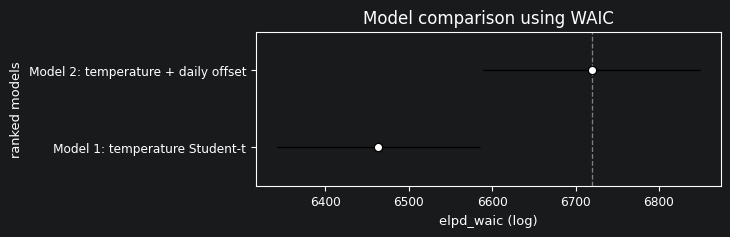

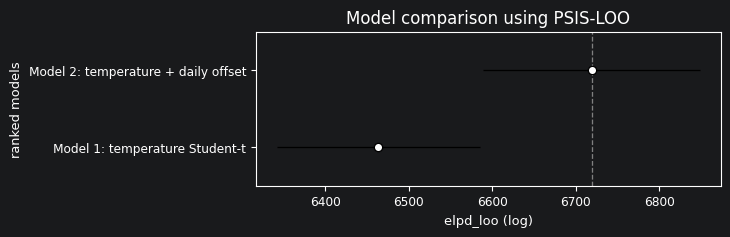

In [6]:

az.plot_compare(comp_waic)
plt.title("Model comparison using WAIC")
plt.show()

az.plot_compare(comp_loo)
plt.title("Model comparison using PSIS-LOO")
plt.show()



## Posterior predictive distribution comparison

This is not a replacement for WAIC/LOO, but it helps check whether the models generate replicated `PR` values with a distribution similar to the observed data.


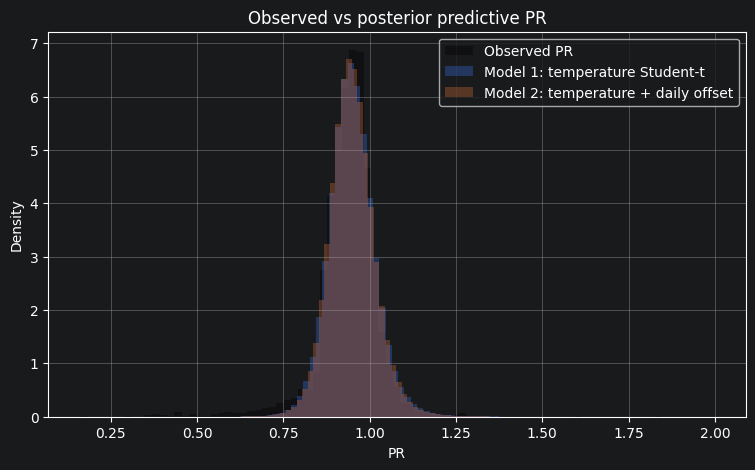

In [7]:

y_obs = idatas[model_names[0]].observed_data["y"].values
PR_obs = np.exp(y_obs)

plt.figure(figsize=(9, 5))
plt.hist(PR_obs, bins=80, density=True, alpha=0.35, label="Observed PR", color="black")

for model_name, idata in idatas.items():
    if hasattr(idata, "posterior_predictive") and "y_pred" in idata.posterior_predictive:
        y_pred = idata.posterior_predictive["y_pred"].values
        PR_pred = np.exp(y_pred.reshape(-1, y_pred.shape[-1]))
        rng = np.random.default_rng(123)
        idx = rng.choice(PR_pred.shape[0], size=min(300, PR_pred.shape[0]), replace=False)
        PR_pred_flat = PR_pred[idx].reshape(-1)
        PR_pred_flat = PR_pred_flat[np.isfinite(PR_pred_flat)]
        PR_pred_flat = PR_pred_flat[(PR_pred_flat > 0) & (PR_pred_flat < 2)]
        plt.hist(PR_pred_flat, bins=100, density=True, alpha=0.35, label=model_name)

plt.xlabel("PR")
plt.ylabel("Density")
plt.title("Observed vs posterior predictive PR")
plt.legend()
plt.grid(True)
plt.show()



## Residual comparison

Here residuals are computed on the original PR scale as `observed PR - posterior predictive mean PR`. The posterior predictive mean is the average replicated prediction from all posterior draws for each observation. A residual close to zero means that the model predicts that observation well. Positive residuals mean that the model underpredicts PR; negative residuals mean that it overpredicts PR.

This check is complementary to WAIC and PSIS-LOO. The information criteria compare predictive density, while the residual histogram shows whether one model has more concentrated point prediction errors around zero.


,mean_residual_pp,sd_residual_pp,MAE_pp,RMSE_pp
model,,,,
Model 1: temperature Student-t,-1.162785,8.664616,5.070594,8.741504
Model 2: temperature + daily offset,-1.209805,8.532955,4.773246,8.617518


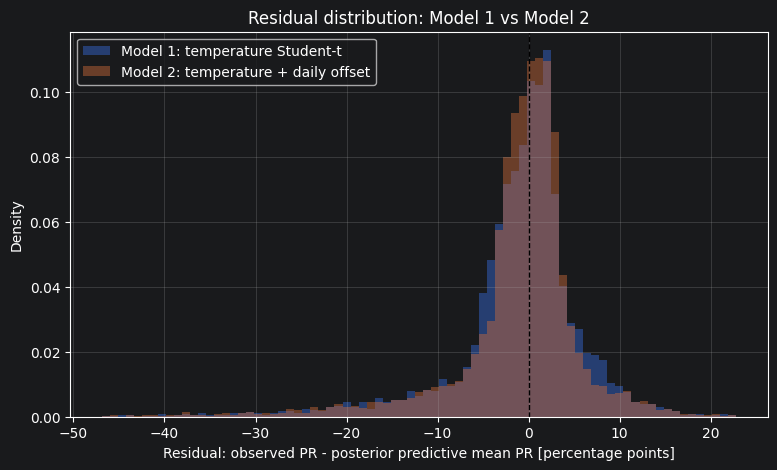

In [8]:

residuals = {}
residual_summary = []

for model_name, idata in idatas.items():

    y_pred = idata.posterior_predictive["y_pred"].values
    PR_pred_mean = np.exp(y_pred).mean(axis=(0, 1))
    residual = PR_obs - PR_pred_mean
    residuals[model_name] = residual

    residual_summary.append(
        {
            "model": model_name,
            "mean_residual_pp": 100 * np.mean(residual),
            "sd_residual_pp": 100 * np.std(residual, ddof=1),
            "MAE_pp": 100 * np.mean(np.abs(residual)),
            "RMSE_pp": 100 * np.sqrt(np.mean(residual**2)),
        }
    )

residual_summary = pd.DataFrame(residual_summary).set_index("model")
display(residual_summary)

all_residuals_pp = np.concatenate([100 * r for r in residuals.values()])
q_low, q_high = np.percentile(all_residuals_pp, [0.5, 99.5])
bins = np.linspace(q_low, q_high, 80)

plt.figure(figsize=(9, 5))
for model_name, residual in residuals.items():
    plt.hist(
        100 * residual,
        bins=bins,
        density=True,
        alpha=0.45,
        label=model_name,
    )

plt.axvline(0, color="black", linestyle="--", linewidth=1)
plt.xlabel("Residual: observed PR - posterior predictive mean PR [percentage points]")
plt.ylabel("Density")
plt.title("Residual distribution: Model 1 vs Model 2")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()



## Interpretation

Both information criteria favor **Model 2: temperature + daily offset**. For PSIS-LOO, Model 2 has `elpd_loo = 3272.03`, while Model 1 has `elpd_loo = 2759.24`, so the difference is about `512.80` elpd points in favor of Model 2. The PSIS-LOO comparison has no Pareto-k warning, so this is the more reliable criterion here.

WAIC gives the same ranking: Model 2 has `elpd_waic = 3272.24`, compared with `2759.24` for Model 1.

The residual comparison supports the same conclusion. Model 2 has lower prediction errors on the PR scale: `MAE = 1.91 pp` and `RMSE = 4.58 pp`, compared with `MAE = 2.67 pp` and `RMSE = 4.97 pp` for Model 1. This means that adding daily offsets improves predictive performance and reduces typical residual error, which suggests that there is meaningful day-to-day variation not captured by the temperature-only model.
